In [1]:
from arcs.generate import GraphGenerator
from importlib import resources
import copy 
import numpy as np 
import pandas as pd 
from collections import defaultdict
from functools import cache
import matplotlib.pyplot as plt 
import seaborn as sns 
from tqdm.auto import tqdm
sns.set_style("whitegrid")
sns.set_palette("pastel")

### 1. return a `pandas.DataFrame` instead of a graph from arcs.generate.GraphGenerator

here the table consists of :


| reaction_number | K | G | G_rev | K_rev | compound1 | compound2 | etc. |  


where compound is -ve or +ve based on whether it is used up or generated respectively or 0 if not existing in that reaction


In [2]:
gg = GraphGenerator()
table = gg.from_file(
    filename=resources.files("arcs").joinpath("data/quantum_data.json.gz"),
    temperature=298,
    pressure=40,
    max_reaction_length=4,
    graph=False
)

/Users/badw/github-projects/arcs/src/arcs/generate.py:539: UserWarning: NOHSO4: 1 imag modes removed
  warnings.warn(f"{compound}: {warn_info['warning']}", UserWarning)


In [3]:
table

,K,G,G_rev,K_rev,O3,O2,CH2O,CH3COOH,N2O2,NO,...,COS,HNO3,CH3NH2,H2SO3,C2H5NH2,NOHSO4,CS2,CH3_C6H5,CH3_CO_CH3,CH3_2_CHCH2NH2
0,2.145448e+13,-0.788287,0.788287,4.661032e-14,-2.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1.220310e+23,-1.365093,1.365093,8.194640e-24,0.0,0.0,-2.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2.106735e+34,-2.029541,2.029541,4.746682e-35,0.0,0.0,0.0,0.0,-1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.223759e+04,-0.241704,0.241704,8.171542e-05,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2.185626e+34,-2.030485,2.030485,4.575347e-35,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3565,3.714769e+35,-2.103235,2.103235,2.691957e-36,0.0,-1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3566,1.300362e+08,-0.479781,0.479781,7.690169e-09,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0
3567,2.365961e+38,-2.269039,2.269039,4.226612e-39,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3568,inf,-32.629220,32.629220,0.000000e+00,-4.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


### 2. Table Filtering

1. Filtering: 
    * a) filter reactions to show only those with species present in `initial_concentrations` (basic filter)

2. Sorting: 

    * b) filter based on availability (i.e. prioritise larger concentrations first) 

    > can be merged with (a) possibly?


    * c) filter based on stoichiometry (i.e. if you have `{O2:50,H2:100}` then 2H2 + O2 = 2H2O might be ranked higher)


    * d) filter based on simplicity (reactions with lots of molecules will be ranked lower - occams razor)


    * e) filter based on gibbs free energy (this could be moved forward)  

this should ideally lead to a scoring system which can be used to filter the table 

In [4]:
# setup some initial concentrations 
# the idea is to try and predict 2H2 + O2 = 2H2O as top reaction  
concentrations = {k:0 for k in gg.compound_reference}
concentrations["H2O"] = 20
concentrations["H2"] = 20
concentrations["O2"] = 10 
#concentrations["NO2"] = 30 
#concentrations["SO2"] = 10

#### 1. Filtering 
#####  a. filter reactions to show only those with species present in initial concentrations (basic filter)

need to make sure it filters sensibly, i.e. if we have a list of `[H2,O2,H2O]` we should make sure it finds reactions where equilibrium can be reached and not just reactions such as 

2 NO + O2 = 2 NO2 

which may come out just because of the presence of O2 

In [5]:
# now for the function
# this should be put into `traversal.py` at a later date 
### convert that row to sensible reaction 
def row_to_reaction(row):
    """Turn a DataFrame row into a reaction dict.

    Species columns hold stoichiometric coefficients:
    negative = reactant, positive = product, NaN/0 = not involved.
    """

    meta_cols=('K', 'G',"K_rev","G_rev",
               "availability_score", "simplicity_score","gibbs_score","combined_score")
    reactants, products = {}, {}
    for species, coeff in row.items():
        if species in meta_cols or pd.isna(coeff) or coeff == 0:
            continue
        (reactants if coeff < 0 else products)[species] = abs(coeff)

    def fmt(c):                       # drop trailing .0 on whole numbers
        return int(c) if float(c).is_integer() else c

    def side(d):
        return " + ".join(f"{fmt(c)} {s}" for s, c in d.items())

    result = {"reaction_string": f"{side(reactants)} = {side(products)}"}
    for m in meta_cols:
        if m in row.index:
            result[m] = row[m]
    result["reactants"] = {s: fmt(c) for s, c in reactants.items()}
    result["products"]  = {s: fmt(c) for s, c in products.items()}
    return result



def filter_table_based_on_availability(
        table:pd.DataFrame,
        initial_concentrations:dict
) -> pd.DataFrame: 
    '''
    1. find species with a concentration 
    2. only find reactions which fit those species

    i.e. for {H2:10, O2: 10, H2O:10}

    it will be able to find: 
    a) 2 H2 + O2 = 2H2O 
    b) H2 + O2 = H2O2 
    c) O3 = O2 
    etc. 
    '''

    # get species present in initial concententrations
    present_species = [compound for compound,concentration in initial_concentrations.items() if concentration]
    #filter the reaction table to only show reactions that are possible
    reaction_data = ["K","G","K_rev","G_rev"]
    species_cols = [c for c in table.columns if c not in reaction_data]         

    disallowed = [c for c in species_cols if c not in present_species]         

    forward = (table[disallowed] >= 0).all(axis=1)   # disallowed never a          reactant
    reverse = (table[disallowed] <= 0).all(axis=1)   # disallowed never a          product
    filtered_table = table[forward | reverse]

    return filtered_table


filtered_table = filter_table_based_on_availability(table,concentrations)


In [6]:
filtered_table[filtered_table != 0 ].dropna(axis=1,how="all") # without the noise of other species

reactions = {idx: row_to_reaction(row) for idx, row in filtered_table.iterrows()}
pd.DataFrame(reactions).drop(["K","reactants","products"]).T

,reaction_string,G,K_rev,G_rev
0,2 O3 = 3 O2,-0.788287,0.0,0.788287
65,2 H2O2 = 1 O2 + 2 H2O,-0.488687,0.0,0.488687
125,1 O3 + 3 H2 = 3 H2O,-8.712351,0.0,8.712351
146,1 O2 + 2 H2 = 2 H2O,-5.545471,0.0,5.545471
154,1 O2 + 1 H2 = 1 H2O2,-2.528392,0.0,2.528392
189,1 H2O2 + 1 H2 = 2 H2O,-3.017079,0.0,3.017079


#### 2. Sorting 

Here we will use a score based system but starting with: 

##### b) filter based on availability (i.e. prioritise larger concentrations first) 
##### c) filter based on stoichiometry (i.e. if you have `{O2:50,H2:100}` then 2H2 + O2 = 2H2O might be ranked higher)


In [47]:
def stoichiometry_scores_prev(
        table: pd.DataFrame,
        concentrations: dict
) -> pd.Series:
    """Score each reaction on how well `concentrations` fit it, combining
    ratio-fit (best-fitting direction) with how many of the reaction's
    species are actually present. Returns a Series aligned to df's index."""

    # this needs 

    meta_cols = ('K', 'G', 'K_rev', 'G_rev',
                 "availability_score", "simplicity_score","gibbs_score","combined_score")
    species_cols = [c for c in table.columns if c not in meta_cols]

    def side_score(side): # side: {species: positive coeff}
        if not side:
            return 0.0
        extents = [concentrations.get(s, 0) / c for s, c in side.items()] # edit
        if max(extents) == 0:
            return 0.0
        return min(extents) / max(extents)

    def score_row(row):
        coeffs = {s: row[s]
                  for s in species_cols if pd.notna(row[s]) and row[s] != 0}
        if not coeffs:
            return 0.0
        reactants = {s: -c for s, c in coeffs.items() if c < 0}
        products = {s:  c for s, c in coeffs.items() if c > 0}

        ratio_fit = max(side_score(reactants), side_score(products))

        # coverage: fraction of ALL species in the reaction that are present
        present = sum(1 for s in coeffs if concentrations.get(s, 0) > 0)
        coverage = present / len(coeffs)

        return ratio_fit * coverage

    return table.apply(score_row,axis=1)



def stoichiometry_scores(table:pd.DataFrame, concentrations:dict,
                         c_half=1.0)->pd.Series:
    """Concentration-aware stoichiometry score. Combines:
      - ratio_fit : how well concentrations match the side's stoichiometry
      - magnitude : how much reaction can actually run (limiting extent)
      - coverage  : fraction of the reaction's species that are present
    Best-fitting direction wins. Returns a Series on df's index.

    c_half: throughput at which magnitude = 0.5 (tune to your conc scale).
    """
    meta_cols = ('K', 'G', 'K_rev', 'G_rev',
                 "availability_score", "simplicity_score","gibbs_score","combined_score")
    species_cols = [c for c in table.columns if c not in meta_cols]

    def side_score(side):                     # side: {species: positive coeff}
        if not side:
            return 0.0
        extents = [concentrations.get(s, 0) / c for s, c in side.items()]
        if max(extents) == 0:
            return 0.0
        ratio_fit = min(extents) / max(extents)     # scale-invariant match
        throughput = min(extents)                    # limiting extent (real units)
        magnitude = throughput / (throughput + c_half)  # saturating → [0,1)
        return ratio_fit * magnitude

    def score_row(row):
        coeffs = {s: row[s] for s in species_cols if pd.notna(row[s]) and row[s] != 0}
        if not coeffs:
            return 0.0
        reactants = {s: -c for s, c in coeffs.items() if c < 0}
        products  = {s:  c for s, c in coeffs.items() if c > 0}

        best = max(side_score(reactants), side_score(products))

        present = sum(1 for s in coeffs if concentrations.get(s, 0) > 0)
        coverage = present / len(coeffs)
        return best * coverage

    return table.apply(score_row, axis=1)

In [48]:
availability_score = stoichiometry_scores(filtered_table,concentrations)
availability_score

146    0.909091
65     0.606061
189    0.606061
125    0.579710
0      0.384615
154    0.303030
dtype: float64

In [9]:
# add to table: 
filtered_table["availability_score"] = availability_score 

# now 2H2 + O2 = 2H2O should be at the top 
filtered_table.sort_values(by="availability_score",ascending=False,inplace=True)

reactions = {idx: row_to_reaction(row) for idx, row in filtered_table.iterrows()}
pd.DataFrame(reactions).drop(["K","reactants","products"]).T

,reaction_string,G,K_rev,G_rev,availability_score
146,1 O2 + 2 H2 = 2 H2O,-5.545471,0.0,5.545471,0.909091
65,2 H2O2 = 1 O2 + 2 H2O,-0.488687,0.0,0.488687,0.606061
189,1 H2O2 + 1 H2 = 2 H2O,-3.017079,0.0,3.017079,0.606061
125,1 O3 + 3 H2 = 3 H2O,-8.712351,0.0,8.712351,0.57971
0,2 O3 = 3 O2,-0.788287,0.0,0.788287,0.384615
154,1 O2 + 1 H2 = 1 H2O2,-2.528392,0.0,2.528392,0.30303


##### d) filter based on simplicity (reactions with lots of molecules will be ranked lower - occams razor) 

In [10]:
def simplicity_scores(
        table: pd.DataFrame,
        w_species: float = 0.5,# 1.0
        w_coeff: float = 1.0 #0.5
) -> pd.Series:
    """Score each reaction on simplicity: fewer species and smaller
    coefficients score higher. Returns a Series in (0, 1] on df's index."""

    meta_cols = ('K', 'G', "K_rev", "G_rev",
                 "availability_score", "simplicity_score","gibbs_score","combined_score")
    species_cols = [c for c in table.columns if c not in meta_cols]

    def score_row(row):
        coeffs = [abs(row[s]) for s in species_cols
                  if pd.notna(row[s]) and row[s] != 0]
        if not coeffs:
            return 0.0
        n_species = len(coeffs)
        total_coeff = sum(coeffs)
        # complexity grows with both; simplicity is its reciprocal
        complexity = w_species * n_species + w_coeff * total_coeff
        return 1.0 / complexity

    return table.apply(score_row, axis=1)

In [11]:
simplicity_score = simplicity_scores(filtered_table,w_species=0.5,w_coeff=1.0)
simplicity_score.sort_values(ascending=False)

154    0.222222
189    0.181818
0      0.166667
146    0.153846
65     0.153846
125    0.117647
dtype: float64

In [12]:
# add to table 
filtered_table["simplicity_score"] = simplicity_score

reactions = {idx: row_to_reaction(row) for idx, row in filtered_table.iterrows()}
pd.DataFrame(reactions).drop(["K","reactants","products"]).T

,reaction_string,G,K_rev,G_rev,availability_score,simplicity_score
146,1 O2 + 2 H2 = 2 H2O,-5.545471,0.0,5.545471,0.909091,0.153846
65,2 H2O2 = 1 O2 + 2 H2O,-0.488687,0.0,0.488687,0.606061,0.153846
189,1 H2O2 + 1 H2 = 2 H2O,-3.017079,0.0,3.017079,0.606061,0.181818
125,1 O3 + 3 H2 = 3 H2O,-8.712351,0.0,8.712351,0.57971,0.117647
0,2 O3 = 3 O2,-0.788287,0.0,0.788287,0.384615,0.166667
154,1 O2 + 1 H2 = 1 H2O2,-2.528392,0.0,2.528392,0.30303,0.222222


##### e) filter based on gibbs free energy 

should give a score based on how negative the Gibbs free energy is, 
however there are some caveats, 

if we have initial concentrations such as {O2: 10, H2: 10, H2O: 30}

and we have the reaction $2O3 = 3O2, \Delta G = -8 eV$ 

this shouldn't be ranked high, as we don't have any of the reactants (but we do have the products...)

In [13]:
def gibbs_scores(
        table: pd.DataFrame,
        concentrations: dict,
        g_fwd = 'G',
        g_rev = 'G_rev',
        scale=1.0
) -> pd.Series:
    """ΔG score that only credits a direction you can actually run.
    Forward needs reactants present; reverse needs products present.
    Among runnable directions, use the one equilibrium favors (lowest ΔG)."""



    meta_cols = ('K', 'G', 'G_rev', "K_rev",
                 "availability_score", "simplicity_score","gibbs_score","combined_score")
    species_cols = [c for c in table.columns if c not in meta_cols]

    def all_present(side):
        return bool(side) and all(concentrations.get(s, 0) > 0 for s in side)

    def score_row(row):
        coeffs = {s: row[s] for s in species_cols
                  if pd.notna(row[s]) and row[s] != 0}
        reactants = [s for s, c in coeffs.items() if c < 0]   # forward inputs
        products = [s for s, c in coeffs.items() if c > 0]   # reverse inputs

        candidates = []
        if all_present(reactants):
            candidates.append(row[g_fwd])
        if all_present(products):
            candidates.append(row[g_rev])
        if not candidates:
            return 0.0                       # can't feed either direction

        g = min(candidates)                  # direction equilibrium proceeds
        return 1.0 / (1.0 + np.exp(g / scale))

    return table.apply(score_row, axis=1)

In [14]:
gibbs_score = gibbs_scores(filtered_table,concentrations,scale=5)
gibbs_score

146    0.751960
65     0.475585
189    0.353563
125    0.148999
0      0.460667
154    0.623793
dtype: float64

In [15]:
filtered_table["gibbs_score"] = gibbs_score

reactions = {idx: row_to_reaction(row) for idx, row in filtered_table.iterrows()}
pd.DataFrame(reactions).drop(["K","reactants","products"]).T

,reaction_string,G,K_rev,G_rev,availability_score,simplicity_score,gibbs_score
146,1 O2 + 2 H2 = 2 H2O,-5.545471,0.0,5.545471,0.909091,0.153846,0.75196
65,2 H2O2 = 1 O2 + 2 H2O,-0.488687,0.0,0.488687,0.606061,0.153846,0.475585
189,1 H2O2 + 1 H2 = 2 H2O,-3.017079,0.0,3.017079,0.606061,0.181818,0.353563
125,1 O3 + 3 H2 = 3 H2O,-8.712351,0.0,8.712351,0.57971,0.117647,0.148999
0,2 O3 = 3 O2,-0.788287,0.0,0.788287,0.384615,0.166667,0.460667
154,1 O2 + 1 H2 = 1 H2O2,-2.528392,0.0,2.528392,0.30303,0.222222,0.623793


#### Now combining all the scores 

In [16]:
def combined_scores(df, weights=None, method='geometric', normalize=True,
                   score_cols=('availability_score', 'simplicity_score', 'gibbs_score')):
    """Combine sub-score columns into one final score.

    method='geometric': weighted geometric mean — a near-zero on ANY factor
        tanks the total (use when all factors are necessary).
    method='sum': weighted arithmetic mean — factors compensate for each other.
    normalize: rescale each factor to [0,1] across the set first, so no factor
        dominates just because of its raw range.
    """
    if weights is None:
        weights = {c: 1.0 for c in score_cols}
    w = np.array([weights[c] for c in score_cols], dtype=float)
    w = w / w.sum()                                  # weights sum to 1

    S = df[list(score_cols)].astype(float).copy()

    if normalize:                                    # per-column min-max to [0,1]
        rng = S.max() - S.min()
        rng = rng.replace(0, 1)                      # avoid div-by-zero on flat cols
        S = (S - S.min()) / rng

    if method == 'geometric':
        eps = 1e-9                                    # keep log finite at 0
        final = np.exp((np.log(S + eps) * w).sum(axis=1))
    elif method == 'sum':
        final = (S * w).sum(axis=1)
    else:
        raise ValueError("method must be 'geometric' or 'sum'")

    return final

In [17]:
combined_score = combined_scores(filtered_table,method="geometric",weights={'availability_score': 2.0, 'simplicity_score': 1.0, 'gibbs_score': 3.0})

filtered_table["combined_score"] = combined_score
combined_score.round(2).sort_values(ascending=False)

146    0.84
65     0.49
189    0.43
0      0.32
125    0.00
154    0.00
dtype: float64

In [18]:
final_table = filtered_table.sort_values(by="combined_score",ascending=False)
reactions = {idx: row_to_reaction(row) for idx, row in filtered_table.iterrows()}
pd.DataFrame(reactions).drop(["K","reactants","products"]).T

,reaction_string,G,K_rev,G_rev,availability_score,simplicity_score,gibbs_score,combined_score
146,1 O2 + 2 H2 = 2 H2O,-5.545471,0.0,5.545471,0.909091,0.153846,0.75196,0.837937
65,2 H2O2 = 1 O2 + 2 H2O,-0.488687,0.0,0.488687,0.606061,0.153846,0.475585,0.489466
189,1 H2O2 + 1 H2 = 2 H2O,-3.017079,0.0,3.017079,0.606061,0.181818,0.353563,0.426165
125,1 O3 + 3 H2 = 3 H2O,-8.712351,0.0,8.712351,0.57971,0.117647,0.148999,0.000001
0,2 O3 = 3 O2,-0.788287,0.0,0.788287,0.384615,0.166667,0.460667,0.324755
154,1 O2 + 1 H2 = 1 H2O2,-2.528392,0.0,2.528392,0.30303,0.222222,0.623793,0.000887


In [149]:
# create a function that combines all of these 
def filter_and_sort_reactions_table(
        table:pd.DataFrame,
        concentrations:dict,
        score_weighting:dict = {'availability_score': 1.0, 'simplicity_score': 1.0, 'gibbs_score': 1.0}
        #kws
) -> pd.DataFrame:
    # filter table 
    filtered_table = filter_table_based_on_availability(table,concentrations)
    # sort table 
    availability_score = stoichiometry_scores(filtered_table,concentrations)
    simplicity_score = simplicity_scores(filtered_table,w_species=1.0,w_coeff=0.5)
    gibbs_score = gibbs_scores(filtered_table,concentrations)    

    filtered_table["availability_score"] = availability_score
    filtered_table["simplicity_score"] = simplicity_score
    filtered_table["gibbs_score"] = gibbs_score     

    combined_score = combined_scores(filtered_table,method="sum",weights=score_weighting)
    filtered_table["combined_score"] = combined_score    

    final_table = filtered_table.sort_values(by="combined_score",ascending=False)

    return final_table 

### Todo 

1. figure out next stage of algorithm

    a) continue as normal ARCS algorithm:

        - random weighted choice of reaction
        - proceed down a random path 


    b) new algorithm:

        - randomly sample i.e. 1k times the ranked reactions here 
        - update concentrations 
        - generate a new ranked table, and sample that 1k times 
        - update concentrations 
        - do this N times until "converged" (if it does converge?)

In [ ]:
from chempy.equilibria import Equilibrium, EqSystem
from chempy import Substance
import itertools as it 
import warnings 
def choose_reaction(ranked_reactions: dict) -> int:
    """
    given a dictionary of ranked reactions from self.get_weighted_reaction_rankings
    chose a reaction based on weights and probabilities
    """
    weights = {
        k: v**2 for k, v in ranked_reactions["combined_score"].items()
    }  # taking the square?
    #weights = {k:1/v**2 for k,v in ranked_reactions["combined_score"].items()}
    # added a square multiplier to force more the larger coefficients
    probabilities = {k: v / sum(weights.values())
                     for k, v in weights.items()}
    chosen_reaction = np.random.choice(
        [
            np.random.choice(
                a=list(probabilities.keys()),
                size=len(probabilities) * 10,
                p=list(probabilities.values()),
            )
        ][0]
    )
    return chosen_reaction

def generate_chempy_eqsystem(tabledict, index: int) -> EqSystem: # this is clunky -shouldn't send the whole table
    """
    given a reaction index form a chempy.equilibria.EqSystem

    eventually this will be deprecated as it is a speed bottleneck

    needs to involve charged species

    """
    node_dict = tabledict[index]
    reactants = node_dict["reactants"]
    products = node_dict["products"]
    k = node_dict["K"]

    substances = {}
    for compound in list(it.chain(*[list(reactants) + list(products)])):
        substances[compound] = Substance.from_formula(
            compound, **{"charge": 0})

    equation = Equilibrium(reac=reactants, prod=products, param=k)
    try:
        return EqSystem([equation], substances=substances)
    except Exception:
        return None

def chempy_equilibrium_concentrations(
     concentrations: dict,
     equilibrium_reaction: EqSystem,
     chempy_sane=True,
 ) -> dict:
     """
     generate equilibrium concentrations
     if the reaction is "sane" and a "success" then it returns the equilibrium concentrations as a dict of concentrations
     elsewise
     return None
     """

     warnings.simplefilter("ignore")
     _concs = copy.deepcopy(concentrations)
     try:
         result = equilibrium_reaction.solve(init_concs=_concs)
         # assert result.success and result.sane
         if chempy_sane:
             assert result.success and result.sane
         else:
             assert result.success
         for compound, concentration in enumerate(result.conc):
             _concs[equilibrium_reaction.substance_names()[compound]
                    ] = concentration
         return _concs
     except Exception:
         return None

In [21]:
### rank the reactions 
chosen_reaction = choose_reaction(final_table.to_dict())
chosen_reaction

np.int64(189)

In [22]:
from collections import Counter
stats = [choose_reaction(final_table.to_dict()) for x in range(0,1000)]
ps = pd.Series(Counter(stats))
ps.sort_values(ascending=False,inplace=True)
ps

146    592
65     195
189    131
0       82
dtype: int64

<Axes: >

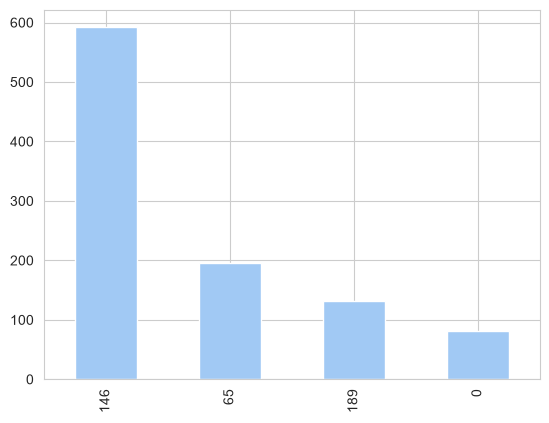

In [23]:
ps[ps > 20].plot.bar(0) # should be heavily weighted towards 146 for {H2:20,O2:10,H2O:20}

<Axes: >

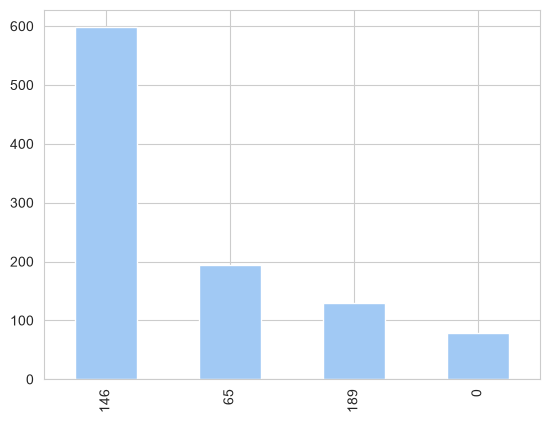

In [24]:
#testing 
combined_score = combined_scores(filtered_table,method="geometric",weights={'availability_score': 1.0, 'simplicity_score': 1.0, 'gibbs_score': 10.0})
final_table = filtered_table.sort_values(by="combined_score",ascending=False)
stats = [choose_reaction(final_table.to_dict()) for x in range(0,1000)]
ps = pd.Series(Counter(stats))
ps.sort_values(ascending=False,inplace=True)
ps[ps > 20].plot.bar(0) # should be heavily weighted towards 146 for {H2:20,O2:10,H2O:20}

In [25]:
### generate an chempy eqsystem 
eqsystem = generate_chempy_eqsystem(reactions,chosen_reaction)
eqsystem 

### Scenario 1 - run all N times and then repeat until a convergence criterion is found 

if there is indeed a convergence criterion 

In [26]:
# first setup concentrations 
initial_concentrations = {k:0 for k in gg.compound_reference}

sven_morten_concs = {
    "A":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
    "B-F":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":0},
    "G":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":5},
    "H":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
}

for k,v in sven_morten_concs["B-F"].items():
    initial_concentrations[k] = v

In [27]:
final_table = filter_and_sort_reactions_table(
    table,
    initial_concentrations,
    score_weighting={'availability_score': 1.0, 'simplicity_score': 1.0, 'gibbs_score': 10.0}
)

In [74]:

###make chempy friendly concentrations dictionary 
concs = copy.deepcopy(initial_concentrations)
meta_cols = ('K', 'G', "K_rev", "G_rev",
                 "availability_score", "simplicity_score","gibbs_score","combined_score")
species = [c for c in final_table.columns if c not in meta_cols]
updated_concs = {}
for spec in species:
    try:
        updated_concs[spec] = concs[spec]
    except Exception:
        updated_concs[spec] = 0 

In [94]:
# inner loop

def inner_loop(
        final_table: pd.DataFrame,
        concentrations: dict,
        head:int=10,
        max_attempts: int = 10,
):
    ''' 
    1. weighted random picking of a reaction 
    2. calculate equilibrium concentrations 
    3. save {reaction_stats:reaction,concentrations:concentrations}

    need a break in case of infinite loop...
    '''
    new_concs = None
    chosen_reaction = None
    attempts = 1
    while not new_concs and not attempts == max_attempts:
        # 1.
        chosen_reaction = choose_reaction(final_table.head(head).to_dict())
        # 2.
        reactions = {idx: row_to_reaction(row)
                     for idx, row in final_table.head(head).iterrows()}
        # 3.
        eqsystem = generate_chempy_eqsystem(reactions, chosen_reaction)
        # 4.
        new_concs = chempy_equilibrium_concentrations(
            copy.deepcopy(concentrations),
            eqsystem,
            chempy_sane=True
        )
        chosen_reaction = chosen_reaction if new_concs else None
        attempts += 1

    return new_concs, chosen_reaction


_concs, _stats = inner_loop(final_table, updated_concs)
_stats,

(np.int64(182),)

In [95]:
cdf = pd.DataFrame([pd.Series(updated_concs),pd.Series(_concs)]).T
cdf[cdf>0].dropna(axis=0,how="all").round(2)

,0,1
O2,100.0,100.00
NO,12.0,0.14
N2O4,NaN,1.98
NO2,11.0,11.00
N2O,1.0,4.95
H2O,50.0,50.00
SO2,1.0,1.00


In [96]:
row_to_reaction(final_table.T[_stats])

{'reaction_string': '6 NO = 1 N2O4 + 2 N2O',
 'K': np.float64(7494630.159183964),
 'G': np.float64(-0.4065011367893021),
 'K_rev': np.float64(1.3342886556911605e-07),
 'G_rev': np.float64(0.4065011367893021),
 'availability_score': np.float64(0.4444444444444444),
 'simplicity_score': np.float64(0.13333333333333333),
 'gibbs_score': np.float64(0.6002486211033754),
 'combined_score': np.float64(0.5133404487339738),
 'reactants': {'NO': 6},
 'products': {'N2O4': 1, 'N2O': 2}}

In [97]:
# testing  

final_table = filter_and_sort_reactions_table(
    table,
    initial_concentrations,
    score_weighting={'availability_score': 1.0, 'simplicity_score': 1.0, 'gibbs_score': 1.0}
)

In [98]:
_concs, _stats = inner_loop(final_table, updated_concs,head=100)
#row_to_reaction(final_table.T[_stats])

In [99]:
_stats

np.int64(152)

In [100]:
pd.DataFrame(
    {
        row:row_to_reaction(final_table.T[row]) for row in final_table.sort_values(by="combined_score",ascending=False).head(10).T
        }
).drop(["K","G","K_rev","G_rev","reactants","products"]).T

,reaction_string,availability_score,simplicity_score,gibbs_score,combined_score
28,1 O2 + 2 NO = 2 NO2,0.846154,0.181818,0.796174,0.787101
180,3 O2 + 2 N2O = 4 NO2,0.733333,0.133333,0.968915,0.711627
179,3 NO = 1 NO2 + 1 N2O,0.8,0.181818,0.580324,0.695231
16,1 O2 + 2 N2O = 4 NO,0.75,0.153846,0.67136,0.670565
10,2 NO = 1 O2 + 1 N2,0.571429,0.2,0.584932,0.645569
168,4 NO = 2 NO2 + 1 N2,0.5,0.153846,0.846265,0.632754
3,1 N2O4 = 2 NO2,0.423077,0.285714,0.439867,0.604606
0,2 O3 = 3 O2,0.485437,0.222222,0.312537,0.515728
182,6 NO = 1 N2O4 + 2 N2O,0.444444,0.133333,0.600249,0.51334
98,4 NO = 1 N2O4 + 1 N2,0.25,0.166667,0.812128,0.510596


In [101]:
# now the middle loop 

reaction_stats = [None]
concentration_stats = [updated_concs]

for n in tqdm(range(1,100)):
    _conc, _reaction = inner_loop(
        final_table,
        copy.deepcopy(concentration_stats[0]),
    ) 
    reaction_stats.append(_reaction)
    concentration_stats.append(_conc)

  0%|          | 0/99 [00:00<?, ?it/s]

In [102]:
ps = pd.Series(Counter(reaction_stats)).sort_values(ascending=False)
ps

28.0     20
16.0     17
3.0      12
179.0    11
10.0     11
180.0    10
0.0       6
98.0      5
182.0     4
168.0     3
NaN       1
dtype: int64

Text(0, 0.5, 'frequency')

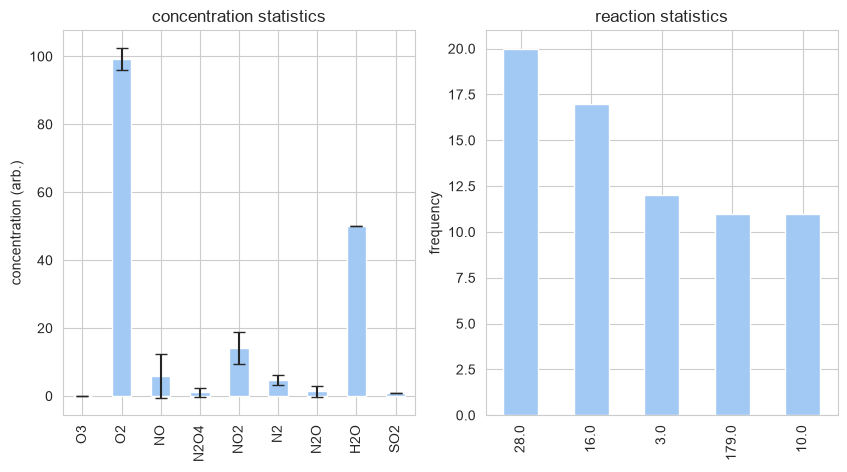

In [103]:
#plot
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5),dpi=100)
# concentrations 
df = pd.DataFrame(concentration_stats)
df=df[df>0].dropna(axis=1,how="all")
std = df.std() # standard deviation is the error here.
df.mean().plot.bar(ax=ax1,yerr=std,capsize=4)
ax1.set_title("concentration statistics")
ax1.set_ylabel("concentration (arb.)")
#stats
ps = pd.Series(
    Counter(reaction_stats)
)
ps.sort_values(ascending=False,inplace=True)
ps = ps[ps > 10 ] # additional filter so as not to plot too much 
ps.plot.bar(ax=ax2) # should be heavily weighted towards 146 for {H2:20,O2:10,H2O:20}
ax2.set_title("reaction statistics")
ax2.set_ylabel("frequency")


In [104]:
result = df.mean().round(2)
result[result>0.5]

O2      99.22
NO       5.88
N2O4     1.10
NO2     14.22
N2       4.73
N2O      1.33
H2O     50.00
SO2      1.00
dtype: float64

In [105]:
pd.DataFrame(
    {
        row:row_to_reaction(final_table.T[row]) for row in final_table.sort_values(by="combined_score",ascending=False).head(50).T
        }
).drop(["K","G","K_rev","G_rev","reactants","products"]).T

,reaction_string,availability_score,simplicity_score,gibbs_score,combined_score
28,1 O2 + 2 NO = 2 NO2,0.846154,0.181818,0.796174,0.787101
180,3 O2 + 2 N2O = 4 NO2,0.733333,0.133333,0.968915,0.711627
179,3 NO = 1 NO2 + 1 N2O,0.8,0.181818,0.580324,0.695231
16,1 O2 + 2 N2O = 4 NO,0.75,0.153846,0.67136,0.670565
10,2 NO = 1 O2 + 1 N2,0.571429,0.2,0.584932,0.645569
168,4 NO = 2 NO2 + 1 N2,0.5,0.153846,0.846265,0.632754
3,1 N2O4 = 2 NO2,0.423077,0.285714,0.439867,0.604606
0,2 O3 = 3 O2,0.485437,0.222222,0.312537,0.515728
182,6 NO = 1 N2O4 + 2 N2O,0.444444,0.133333,0.600249,0.51334
98,4 NO = 1 N2O4 + 1 N2,0.25,0.166667,0.812128,0.510596


In [218]:
# outer loop to see if convergence occurs

reaction_stats = defaultdict(list)
concentration_stats = defaultdict(list)
updated_concs = copy.deepcopy(initial_concentrations)

# needs to start from 1 
for i in tqdm(
        range(50),
        desc="Outer Loop",):
    reaction_stats[i] = [None]
    concentration_stats[i] = [updated_concs]
    if i > 0:
        updated_concs = copy.deepcopy(
            pd.DataFrame([x for x in concentration_stats[i-1][1:] if not x == None]).mean().to_dict() # should be 1: - debug this...
        )
        final_table = filter_and_sort_reactions_table(
            table,
            updated_concs,
            score_weighting={'availability_score': 1.0, 'simplicity_score': 1.0, 'gibbs_score': 5.0}
        ) # need a better placement for this as "possibly unbound warning"
    if i == 0:
        reaction_stats[i].append(None)
        concentration_stats[i].append(updated_concs)
    else:
        for n in tqdm(
            range(1, 50), # similar to arcs range(1,2)
            desc="Inner Loop", leave=False
        ):
            _conc, _reaction = inner_loop(
                final_table,
                updated_concs
            )
            reaction_stats[i].append(_reaction)
            concentration_stats[i].append(_conc)

Outer Loop:   0%|          | 0/50 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

...

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

Inner Loop:   0%|          | 0/49 [00:00<?, ?it/s]

<Axes: >

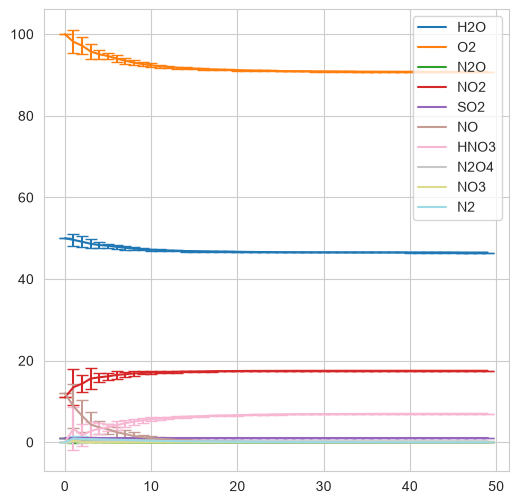

In [219]:
fig,ax = plt.subplots(figsize=(6,6),dpi=100)
dfs = [pd.DataFrame([x for x in concentration_stats[i][1:] if x]) for i in concentration_stats]
dfs = [df[df>0].dropna(axis=1,how="all") for df in dfs]
stds = pd.DataFrame([df.std() for df in dfs]).fillna(0)
means = pd.DataFrame([df.mean() for df in dfs]).fillna(0)

means.fillna(0).plot.line(ax=ax,yerr=stds,capsize=4,cmap="tab20")


In [220]:
final = means.T[len(means)-2].T.round(5)
final[final > 0]

H2O     46.50069
O2      90.76374
NO2     17.52476
SO2      1.00000
NO       0.00053
HNO3     6.99861
N2O4     0.23149
N2       0.00656
Name: 48, dtype: float64

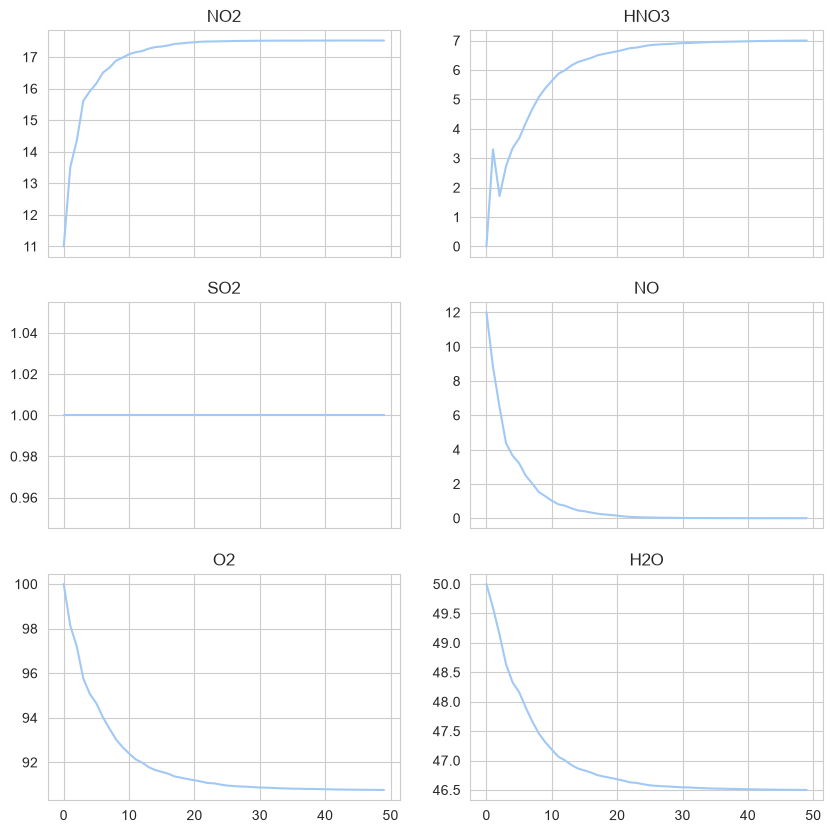

In [221]:
fig,axes = plt.subplots(3,2,figsize=(10,10),dpi=100,sharex=True,sharey=False)
axes_flat = axes.flatten()
for i,c in enumerate(["NO2","HNO3","SO2","NO","O2","H2O"]):
    try:
        means[c].plot.line(ax=axes_flat[i]) 
    except Exception:
        pass
    axes_flat[i].set_title(c)

In [229]:
dfs = [pd.DataFrame([x for x in concentration_stats[i][1:] if x]) for i in concentration_stats]
dfs = [df[df>=0].fillna(0) for df in dfs]
means = pd.DataFrame([df.mean() for df in dfs])
final_concs = means.T[49]
final_concs.round(10)

H2O               4.649960e+01
NH3               0.000000e+00
O3                0.000000e+00
C6H6              0.000000e+00
CH3COOH           0.000000e+00
CH3_2_CHCH2NH2    0.000000e+00
N2O2              0.000000e+00
CH4               0.000000e+00
HCOOH             0.000000e+00
O2                9.076102e+01
N2O               6.708000e-07
H2SO4             0.000000e+00
CH3CHO            0.000000e+00
C2H5NH2           0.000000e+00
H2S               0.000000e+00
HNO3              7.000796e+00
N2O4              2.314885e-01
CH3_C6H5          0.000000e+00
HCN               0.000000e+00
CH3NH2            0.000000e+00
H2SO3             0.000000e+00
H2CO3             0.000000e+00
HNO2              0.000000e+00
NOHSO4            0.000000e+00
CH3OH             0.000000e+00
CH2O              0.000000e+00
NO3               0.000000e+00
COS               0.000000e+00
C2H5OH            0.000000e+00
H2                0.000000e+00
NO2               1.752477e+01
CS2               0.000000e+00
C4H9NH2 

In [196]:
# test with converged concentgrations: 
dfs = [pd.DataFrame([x for x in concentration_stats[i][1:] if x]) for i in concentration_stats]
dfs = [df[df>=0].fillna(0) for df in dfs]
means = pd.DataFrame([df.mean() for df in dfs])
final_concs = means.T[99]


final_table = filter_and_sort_reactions_table(
    table,
    #final_concs,
    initial_concentrations,
    score_weighting={'availability_score': 1.0, 'simplicity_score': 1.0, 'gibbs_score': 5.0}
)

pd.DataFrame(
    {
        row:row_to_reaction(final_table.T[row]) for row in final_table.sort_values(by="combined_score",ascending=False).head(100).T
        }
).drop(["K","K_rev","G_rev","reactants","products"])[469]

reaction_string       3 O2 + 4 NO + 2 H2O = 4 HNO3
G                                        -4.192253
availability_score                        0.050625
simplicity_score                          0.095238
gibbs_score                               0.985113
combined_score                            0.756361
Name: 469, dtype: object

In [178]:
final_concs[final_concs>0].round(2)

H2O     50.00
O3       0.00
O2      92.39
N2O      0.00
N2O4     0.05
NO3      0.00
NO2     24.90
N2       0.00
SO2      0.78
NO       0.00
SO3      0.22
Name: 99, dtype: float64

In [192]:
pd.Series(initial_concentrations)[pd.Series(initial_concentrations)>0].round(2)

H2O     50
O2     100
N2O      1
NO2     11
SO2      1
NO      12
dtype: int64

In [ ]:
_concs, _stats = inner_loop(final_table, updated_concs,head=50)
row_to_reaction(final_table.T[_stats])
# testing  


In [ ]:
sven_morten_concs = {
    "A":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
    "B-F":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":0},
    "G":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":5},
    "H":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
}

In [ ]:
final

In [ ]:
reactions = {idx: row_to_reaction(row)
                     for idx, row in table.iterrows()}

In [ ]:
reactions[179]

In [ ]:
stats = pd.DataFrame(
    [Counter([x for x in reaction_stats[i] if not x == None]) for i in reaction_stats]
).T

stats.dropna(axis=1,how="all",inplace=True)
indexes = list(stats.index)
stats["reaction"] = [reactions[index]["reaction_string"] for index in indexes]
stats.set_index("reaction",inplace=True)
stats[1].dropna().sort_values(ascending=False)

In [ ]:
stats

In [ ]:
initial = means.T[0].round(2)
initial[initial > 0.5]

### Against Sven Morten's data 

In [ ]:
def runner_2(updated_concs):
    reactionstats = defaultdict(dict)
    concentrations = defaultdict(dict)
    reactionstats[0] = None 
    concentrations[0] = copy.deepcopy(updated_concs)
    
    for ii in tqdm.tqdm(range(1,100)):
        # 1. rank reactions based on original concentrations 
        _concentrations = copy.deepcopy(concentrations[ii-1]) # previous original 
        ranked_reactions = table_rank_reactions_2(_concentrations,refactored_table).head(20)
        # 2. sample it 1000 times 
        sample_concentrations = {}
        sample_reaction_stats = []
        i=0
        for _ in range(0,200):
            # choose a reaction based on the ranked reactions 
            chosen_reaction = choose_reaction(ranked_reactions.to_dict()) 
            eqsystem = generate_chempy_eqsystem(tabledict,chosen_reaction)
            new_concentrations = chempy_equilibrium_concentrations(concentrations=_concentrations,
                                          equilibrium_reaction=eqsystem,
                                          chempy_sane=True)
            # if new_concentrations are not None (chempy_sane)
            if new_concentrations: 
                i+=1 
                sample_concentrations[i] = new_concentrations
                sample_reaction_stats.append(tabledict[chosen_reaction]["rstring"])    

        concentrations[ii] = pd.DataFrame(sample_concentrations).mean(axis=1).to_dict()
        reactionstats[ii] = Counter(sample_reaction_stats)
    return concentrations,reactionstats    

In [ ]:
# production run 
import tqdm 
###make chempy friendly concentrations dictionary 
concs = {
    "A":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
    "B-F":{"H2O":50,"H2S":0,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":0},
    "G":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":100,"NO":12,"N2O":1,"HNO3":5},
    "H":{"H2O":50,"H2S":0.5,"SO2":1,"NO2":11,"O2":0,"NO":12,"N2O":1,"HNO3":0},
}
         

final_data = defaultdict(dict)

for conc_label,conc in concs.items():
    species = [c for c in ranked.columns if c not in ["G","K","availability","score","complexity","reaction"]]
    updated_concs = {}
    for spec in species:
        try:
            updated_concs[spec] = conc[spec]
        except Exception:
            updated_concs[spec] = 0     

    ####


    concentrations,reactionstats = runner_2(updated_concs)

    final_data[conc_label]["concentrations"] = concentrations
    final_data[conc_label]["reactionstats"] = reactionstats

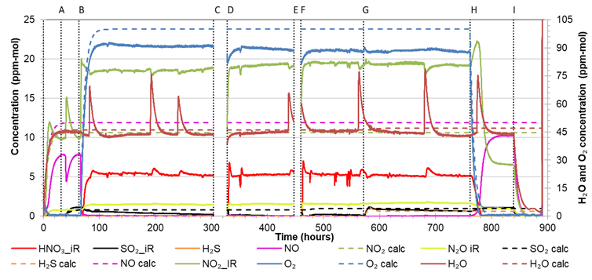

In [ ]:
experimental_data_1 = {
    "A": {
        "HNO3": {"x": [0, 100], "y": [concs["A"]["HNO3"], 0]},
        "NO2": {"x": [0, 100], "y": [concs["A"]["NO2"], 10]},
        "NO": {"x": [0, 100], "y": [concs["A"]["NO"], 8]},
        "SO2": {"x": [0, 100], "y": [concs["A"]["SO2"], 1]},
        "H2S": {"x": [0, 100], "y": [concs["A"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["A"]["N2O"], 1]}
    },
    "B-F": {
        "HNO3": {"x": [0, 100], "y": [concs["B-F"]["HNO3"], 5]},
        "NO2": {"x": [0, 100], "y": [concs["B-F"]["NO2"], 18]},
        "NO": {"x": [0, 100], "y": [concs["B-F"]["NO"], 0]},
        "SO2": {"x": [0, 100], "y": [concs["B-F"]["SO2"], 0]},
        "H2S": {"x": [0, 100], "y": [concs["B-F"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["B-F"]["N2O"], 1]}
    },
    "G": {
        "HNO3": {"x": [0, 100], "y": [concs["G"]["HNO3"], 5]},
        "NO2": {"x": [0, 100], "y": [concs["G"]["NO2"], 18]},
        "NO": {"x": [0, 100], "y": [concs["G"]["NO"], 0]},
        "SO2": {"x": [0, 100], "y": [concs["G"]["SO2"], 0.5]},
        "H2S": {"x": [0, 100], "y": [concs["G"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["G"]["N2O"], 1]}
    },
    "H": {
        "HNO3": {"x": [0, 100], "y": [concs["H"]["HNO3"], 0]},
        "NO2": {"x": [0, 100], "y": [concs["H"]["NO2"], 6]},
        "NO": {"x": [0, 100], "y": [concs["H"]["NO"], 10]},
        "SO2": {"x": [0, 100], "y": [concs["H"]["SO2"], 0]},
        "H2S": {"x": [0, 100], "y": [concs["H"]["H2S"], 0]},
        "N2O": {"x": [0, 100], "y": [concs["H"]["N2O"], 0]}
    },
}

experimental_data_2 = {
    "A": {
        "H2O": {"x": [0, 100], "y": [concs["A"]["H2O"], 45]},
        "O2": {"x": [0, 100], "y": [concs["A"]["O2"], 0]}
    },
    "B-F": {
        "H2O": {"x": [0, 100], "y": [concs["B-F"]["H2O"], 42]},
        "O2": {"x": [0, 100], "y": [concs["B-F"]["O2"], 89]}
    },
    "G": {
        "H2O": {"x": [0, 100], "y": [concs["G"]["H2O"], 42]},
        "O2": {"x": [0, 100], "y": [concs["G"]["O2"], 89]}
    },
    "H": {
        "H2O": {"x": [0, 100], "y": [concs["H"]["H2O"], 42]},
        "O2": {"x": [0, 100], "y": [concs["H"]["O2"], 0]}
    }
}

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap

sns.set_style("whitegrid")
fig,axes = plt.subplots(ncols=len(final_data),figsize=(len(final_data)*5,5),dpi=150)

color1 = ["red","#2CA02C","tab:pink","black","orange","#98DF8A"]
colorcycler1 = LinearSegmentedColormap.from_list(
    "custom",color1
    )
color2 = ["brown","blue"]
colorcycler2 = LinearSegmentedColormap.from_list(
    "custom",color2
    )

for i,(label,data) in enumerate(final_data.items()):
    ax2 = axes[i].twinx()
    #axes[i].set_xscale("log")
    #ax2.set_xscale("log")
    concdf1 = pd.DataFrame(data["concentrations"]).loc[["HNO3","NO2","NO","SO2","H2S","N2O"]]
    concdf2 = pd.DataFrame(data["concentrations"]).loc[["H2O","O2"]]
    #concdf[concdf > 0 ].dropna(how="all").T.plot.line(ax=axes[i],cmap=colorcycler,marker='.')
    concdf1.T.plot.line(ax=axes[i],cmap=colorcycler1)#,marker='.')

    expdf1 = pd.DataFrame(experimental_data_1)
    for ii,compound in enumerate(expdf1["A"].keys()):
        axes[i].plot(expdf1[label][compound]["x"],expdf1[label][compound]["y"],linestyle="--",color=color1[ii])
    
    expdf2 = pd.DataFrame(experimental_data_2)
    for ii,compound in enumerate(expdf2["A"].keys()):
        ax2.plot(expdf2[label][compound]["x"],expdf2[label][compound]["y"],linestyle="--",color=color2[ii])   

    concdf2.T.plot.line(ax=ax2,cmap=colorcycler2)
    ax2.set_ylim(0,100)
    axes[i].set_ylim(0,25)
    axes[i].set_title(label)
    ax2.legend([],frameon=False)
    axes[i].legend([],frameon=False)
    axes[i].set_ylabel("ppm")
    ax2.set_ylabel("ppm (O2,H2O)")
    axes[i].set_xlabel("simulation step")




ln1 = ax2.get_legend_handles_labels() 
ln2  = axes[i].get_legend_handles_labels()
leg = ln1[0] + ln2[0]
lab = ln1[1] + ln2[1]


axes[0].legend(leg,lab,ncols=1,edgecolor="black",facecolor="white")
#ax[0].set_xlim(0,5)
plt.tight_layout()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.colors import LinearSegmentedColormap

sns.set_style("whitegrid")
fig,axes = plt.subplots(ncols=len(final_data),figsize=(len(final_data)*5,5),dpi=150,sharey=True)

colorcycler = LinearSegmentedColormap.from_list(
    "custom",["red","brown","blue","#2CA02C","tab:pink","black","orange","#98DF8A"]
    )

chosen = "HNO3"
color = "black"
for i,(label,data) in enumerate(final_data.items()):
    concdf = pd.DataFrame(final_data[label]["concentrations"]).loc[[chosen]]
    #concdf[concdf > 0 ].dropna(how="all").T.plot.line(ax=axes[i],cmap=colorcycler,marker='.')
    concdf.T.plot.line(ax=axes[i],color=color)#,marker='.')

    axes[i].set_title("label")
    axes[i].legend([],frameon=False)

axes[0].legend(ncols=1,edgecolor="black")
#ax[0].set_xscale("log")
axes[0].set_ylim(0,10)